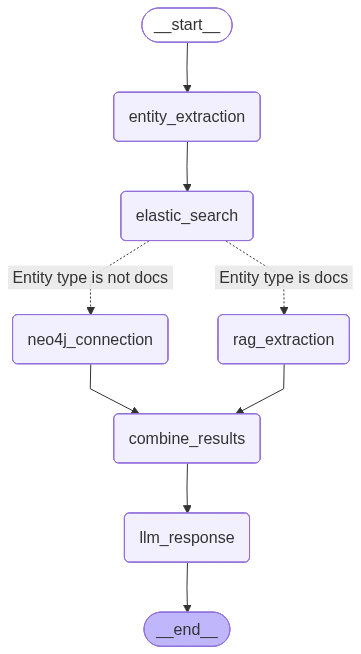

In [18]:
from langchain_openai import ChatOpenAI 
from langgraph.graph import MessagesState, StateGraph, START, END
from typing import List
from IPython.display import Image, display

class State(MessagesState):
    entities: List[dict] = []
    es_results: List[dict] = []
    neo4j_results: List[dict] = []
    rag_results: List[dict] = []
    is_useful: bool = False

def entity_extraction(state: State):
    """
    Extract entities from the input text using a language model.
    Output: [{'entity_1': 'name_1'}, {'entity_2': 'name_2'}, ...]
    """
    # Mock implementation - replace with actual entity extraction logic
    entities = [{'entity': 'document', 'type': 'file'}, {'entity': 'patient', 'type': 'person'}]
    return {"entities": entities}

def elastic_search(state: State):
    """Compare the extracted entities with an elastic search index
    Output: [{'entity_1': 'name_1', 'matched': True, 'metadata': {}}]
    """ 
    # Mock implementation - replace with actual Elasticsearch logic
    es_results = []
    for entity in state['entities']:
        es_results.append({
            'entity': entity['entity'],
            'type': entity['type'],
            'matched': True, 
            'metadata': {},
            'tool_needed': 'rag' if entity['type'] == 'file' or entity['entity'] == 'document' else 'neo4j'
        })
    return {"es_results": es_results}

def tool_router(state: State):
    """
    Route to appropriate tool based on entity type
    """
    # Check if any entities need RAG processing
    needs_rag = any(result.get('tool_needed') == 'rag' for result in state['es_results'])
    needs_neo4j = any(result.get('tool_needed') == 'neo4j' for result in state['es_results'])
    
    if needs_rag and needs_neo4j:
        return "both"
    elif needs_rag:
        return "rag"
    elif needs_neo4j:
        return "neo4j"
    else:
        return "llm_response"

def rag_extraction(state: State):
    """
    Use RAG to extract information from documents
    """
    # Mock implementation - replace with actual RAG logic
    rag_results = []
    for result in state['es_results']:
        if result.get('tool_needed') == 'rag':
            rag_results.append({
                **result,
                'rag_content': f"RAG extracted content for {result['entity']}",
                'relevance_score': 0.85
            })
    return {"rag_results": rag_results}

def neo4j_connection_between_entities(state: State):
    """Find the connections between the entities in a neo4j graph database and return the json
    Output: [{'entity_1': 'name_1', 'matched': True, 'metadata': {}, 'connections': [{'entity_2': 'name_2', 'relation': 'relation_type'}]}]
    """
    # Mock implementation - replace with actual Neo4j logic
    neo4j_results = []
    for result in state['es_results']:
        if result.get('tool_needed') == 'neo4j':
            neo4j_results.append({
                **result,
                'connections': [{'entity_2': 'connected_entity', 'relation': 'RELATED_TO'}]
            })
    return {"neo4j_results": neo4j_results}

def llm_response(state: State):
    """
    Generate a response to the user based on the information found
    """
    # Mock implementation - replace with actual response generation logic
    rag_count = len(state.get('rag_results', []))
    neo4j_count = len(state.get('neo4j_results', []))
    
    response = f"Analysis complete. Found {rag_count} document entities and {neo4j_count} graph entities with connections."
    return {"messages": [{"role": "assistant", "content": response}]}

def combine_results(state: State):
    """
    Combine RAG and Neo4j results into a single state attribute
    """
    combined = {
        'rag_results': state.get('rag_results', []),
        'neo4j_results': state.get('neo4j_results', [])
    }
    return {"combined_results": combined}

# Create the workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("entity_extraction", entity_extraction)
workflow.add_node("elastic_search", elastic_search)
workflow.add_node("rag_extraction", rag_extraction)
workflow.add_node("neo4j_connection", neo4j_connection_between_entities)
workflow.add_node("llm_response", llm_response)
workflow.add_node('combine_results', combine_results)
# Add edges
workflow.add_edge(START, "entity_extraction")
workflow.add_edge("entity_extraction", "elastic_search")

# Add conditional edges from elastic_search based on tool routing
workflow.add_conditional_edges(
    "elastic_search",
    tool_router,
    {
        "Entity type is docs": "rag_extraction",
        "Entity type is not docs": "neo4j_connection", 
    }
)

# Connect RAG to Neo4j if both are needed, otherwise to LLM response
workflow.add_edge("rag_extraction", "combine_results")
workflow.add_edge("neo4j_connection", "combine_results")
workflow.add_edge("combine_results", "llm_response")
workflow.add_edge("llm_response", END)

# Set entry point
workflow.set_entry_point("entity_extraction")

# Compile the graph
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# Extract entity

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
import json 
model = ChatOpenAI(model="gpt-4o",temperature=0)

def entity_extraction(text):
    model = ChatOpenAI(model="gpt-4", temperature=0)
    system_message = system_message = """
      You are an information extraction assistant.

      Task:
      - Extract all entities mentioned in the given text.
      - Return the result as a list of dictionaries.
      - Each dictionary must have two keys:
        - "entity": the exact text of the entity
        - "type": the category of the entity can only be: plan, facility, doctor
      _ If there are no entities, or the entities does not belong to the list of entity above, return an empty list.

      Input format example:
      "What should I know about my Gold Plus 500 plan and can you recommend a doctor in New York?"
      Output format example:
      [
        {"entity": "Gold Plus 500", "type": "plan"},
        {"entity": "doctor", "type": "doctor"},
        {"entity": "New York", "type": "facility"}
      ]
      """

    messages = [SystemMessage(content =system_message), HumanMessage(content=text)]
    response = model.invoke(messages)
    return json.loads(response.content)

In [20]:
entity_extraction("What should I know about my MyBlue Health Gold 403 plan and can you recommend a doctor in New York?")
# entity_extraction("Where can I find Dr. Sarah Johnson andwhat does my Silver Health coverage include?")
entity_extraction("what is the coinsurance for my MyBlue Health Gold 403 plan?")



[{'entity': 'MyBlue Health Gold 403', 'type': 'plan'}]

In [21]:
#[{'entity': 'MyBlue Health Gold 403', 'type': 'plan', 'table': 'plans.csv', 'related_columns': ['pdf_url']}] -> text_to_sql -> rows of info -> ReAct agent [tool pdf extraction]  